---

MD004 - Algoritmos de Clustering (A: 8/01/2026) (B: 12/01/2026)

## Ejemplo clustering por centroides

**¿Qué es K-means?** <br><br>

K-means es un algoritmo de aprendizaje no supervisado que agrupa los datos en $k$ clústeres, donde $k$ debe definirse antes de ejecutar el algoritmo. El objetivo es que los puntos dentro de un mismo clúster sean lo más similares posible entre sí y lo más diferentes posible de los de otros clústeres.

A diferencia del clustering jerárquico, K-means no construye una jerarquía, sino una partición directa de los datos.<br><br>

**¿Cómo se mide la "cercanía"?**
- Métrica de Distancia: primero, el algoritmo necesita saber cuán lejos está un punto $A$ de un punto $B$ (con: distancia Euclidiana, distancia manhattan, etc.)
<br><br>



<div align="center">
    <div align="center">
        <div style="display:flex; justify-content:center; gap:16px; flex-wrap:wrap;">
            <img src="https://media.geeksforgeeks.org/wp-content/uploads/20250103121010720223/Kmeans-implementation.png" alt="Resultados k-means" style="width:800; height:auto;" />
        </div>
    </div>
</div>

<br><br>

**¿Que se debe hacer en este notebook?** <br><br>

Teneis que hacer import del csv ``fish_data.csv``, estudiar las variables/hacer un EDA y finalmente utilizar la librería ``scipy.cluster`` para hacer los clusters y visualizarlos

<br><br>

**Dataset:**
- [Ver el dataset en Kaggle — Fish Species (weight & height)](https://www.kaggle.com/datasets/taweilo/fish-species-sampling-weight-and-height-data?resource=download)

<br><br>

---


### **0. Imports y carga de datos**

In [93]:
import pandas as pd # Librería Pandas, es muy útil para el manejo de datos en ML
import numpy as np # Librería Numpy, se usa para operaciones matemáticas más eficientes

# Librería Scipy
from scipy.cluster import hierarchy # Utilizada para calcular la matriz de enlaces (linkage) y visualizar el dendrograma
from scipy.cluster.hierarchy import fcluster # Para conseguir los resultados del clustering
import scipy.stats as stats # Utilizada para tests estadísticos

# Librería Sklearn
from sklearn.preprocessing import StandardScaler # Para escalar los datos
from sklearn.metrics import silhouette_score # Para calcular el rendimiento del clustering
from sklearn.cluster import AgglomerativeClustering # Es la versión de Sklearn de "scipy.cluster"
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.decomposition import  PCA
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

# Librería MatplotLib
import matplotlib.pyplot as plt # Para personalizar los gráficos del dendrograma
import matplotlib.gridspec as gridspec # Para tener graficas compuestas

import plotly.express as px # Librería Plotly, para generar gráficos 3D (normalmente no la usaréis, solamente es para un ejemplo concreto ya que solamente tenemos 3 variables en el dataset)

import seaborn as sns # Librería Seaborn, para personalizar los gráficos

In [2]:
# Cargamos el dataset
dataset = pd.read_csv("../fish_data.csv")

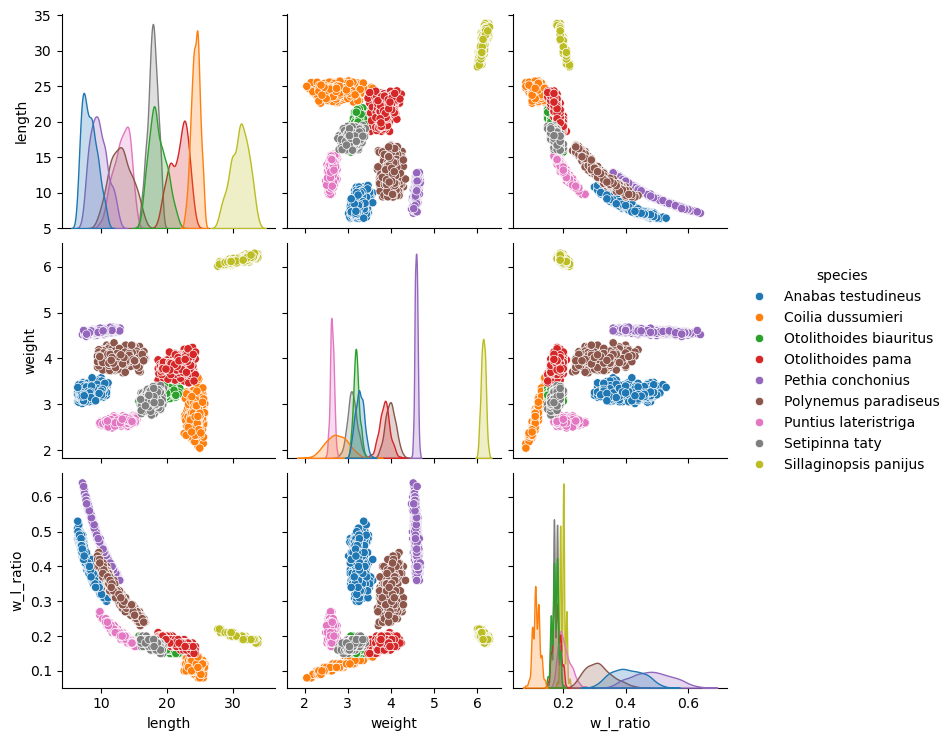

In [3]:
sns.pairplot(data=dataset, hue="species")
plt.show()

Para poder comparar los modelos mejor, vamos a crear una tabla para guardar los resultados.

In [4]:
results = pd.DataFrame(columns=["Name", "Silhouette Score", "Adjusted Rand Score (ARS)", "Params"])

##### **1. K-means**

In [5]:
x = dataset.drop(columns=["species"])
y = dataset["species"]

In [6]:
# Creamos modelo
model = KMeans(random_state=43)

# Entrenamos modelo
model.fit(x)

# Entrenamos hacemos predicción
pred = model.predict(x)

# Evaluamos modelo
score = silhouette_score(x, model.labels_)
print(f"Silhouette Score: {score}")

ari = adjusted_rand_score(y, model.labels_)
print(f"Adjusted Rand Index: {ari}")

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

Silhouette Score: 0.5309452237974256
Adjusted Rand Index: 0.5503728944888617


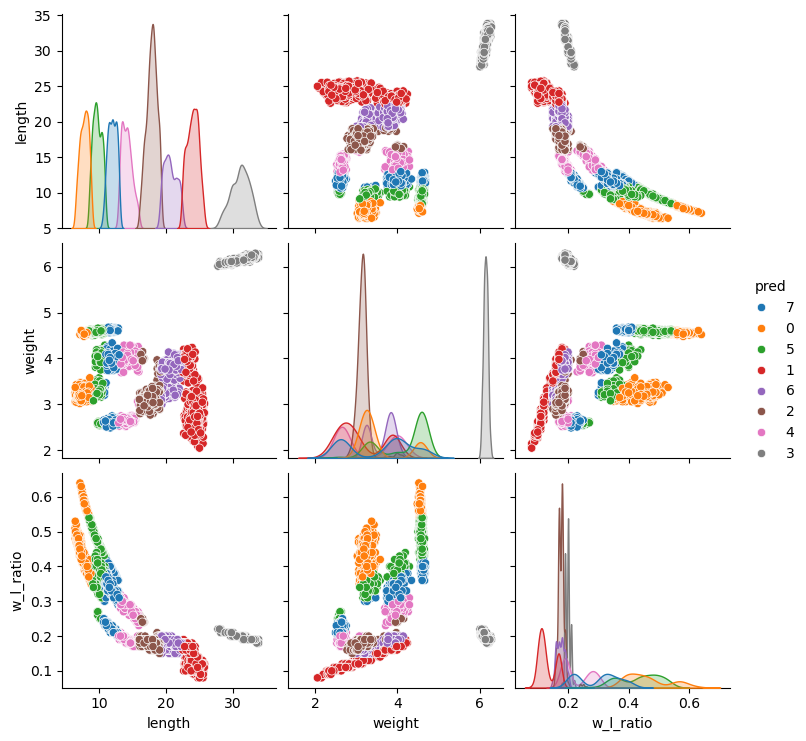

In [7]:
x = x.copy()
x["pred"] = model.labels_.astype(str)

sns.pairplot(x, hue="pred")
plt.show()

In [8]:
results.loc[len(results)] = ["First try", score, ari, model.get_params()]
results

,Name,Silhouette Score,Adjusted Rand Score (ARS),Params
0,First try,0.530945,0.550373,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."


---

<br>

#### ¿Que está pasando?
#### ¿Como se puede mejorar el modelo?

<br>

---

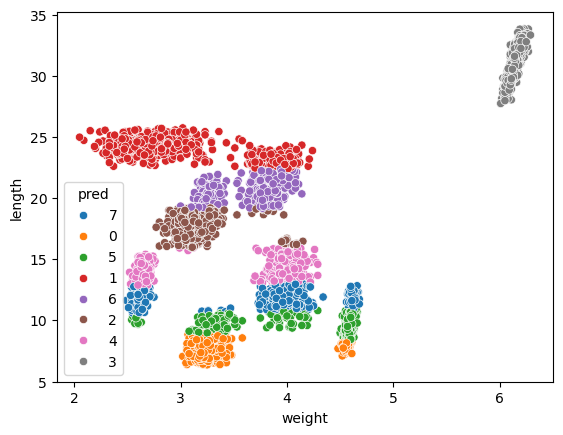

In [9]:
sns.scatterplot(data = x, x = "weight", y = "length", hue = "pred")
plt.show()

In [10]:
centroids = (x.groupby("pred")[["weight", "length"]].mean())

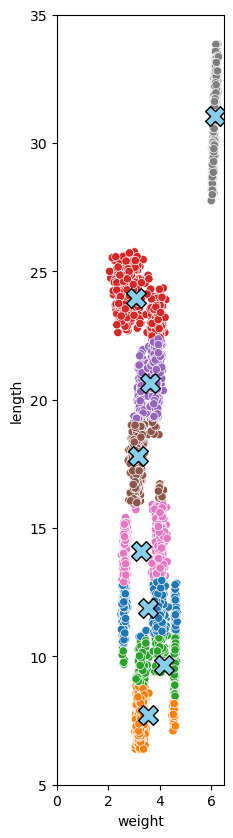

In [11]:
plt.figure(figsize=(10, 10))

# Limitamos los ejes
plt.xlim(0, 6.5)
plt.ylim(5, 35)

# Hacemos que sea proporcional
plt.gca().set_aspect('equal', adjustable='box') 

sns.scatterplot(data = x, x = "weight", y = "length", hue = "pred")
plt.scatter(centroids["weight"], centroids["length"], marker="X", edgecolors="black", c="skyblue", s=200)
plt.legend().set_visible(False)
plt.show()


---

### Kmeans scaled

In [12]:
cols = ["length", "weight", "w_l_ratio"]

scaler = StandardScaler()
dataset_scal = scaler.fit_transform(dataset[cols])

In [13]:
x = dataset.drop(columns=["species"])
x_scal = scaler.fit_transform(x)
x = pd.DataFrame(x_scal, columns = x.columns, index = x.index)
y = dataset["species"]

In [14]:
model = KMeans()

model.fit(x)

score = silhouette_score(x, model.labels_)
print(f"Silhouette Score: {score}")

ari = adjusted_rand_score(y, model.labels_)
print(f"Adjusted Rand Index: {ari}") 

Silhouette Score: 0.6551720293693125
Adjusted Rand Index: 0.8338814067786215


In [15]:
results.loc[len(results)] = ["Scaled", score, ari, model.get_params()]
results

,Name,Silhouette Score,Adjusted Rand Score (ARS),Params
0,First try,0.530945,0.550373,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."
1,Scaled,0.655172,0.833881,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."


In [16]:
x = x.copy()
x["pred"] = model.labels_.astype(str)

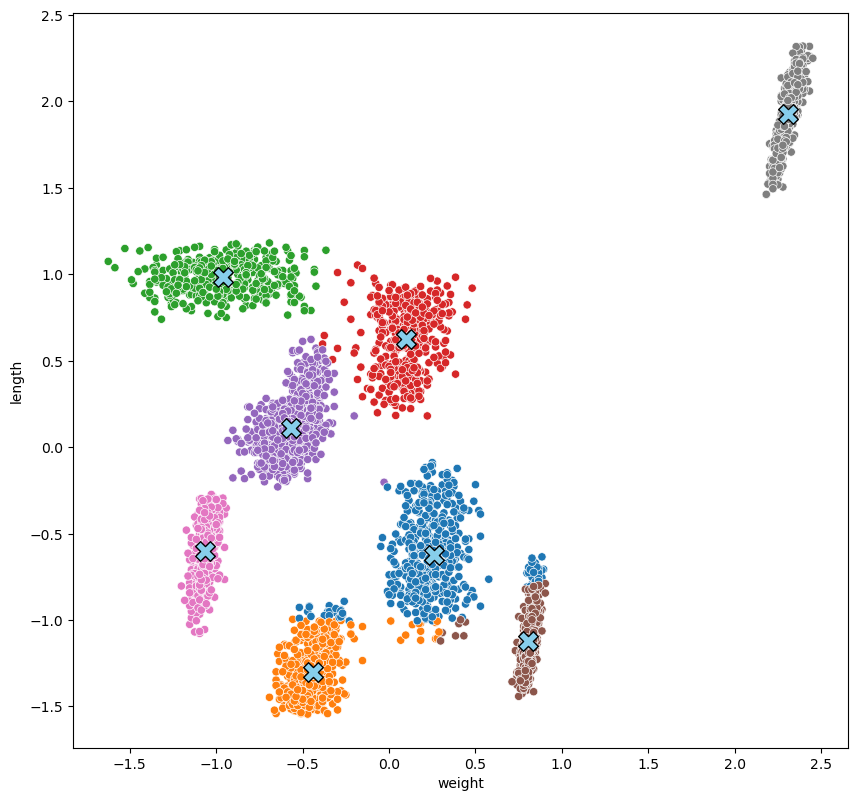

In [17]:
centroids = (x.groupby("pred")[["weight", "length"]].mean())

plt.figure(figsize=(10, 10))

# Hacemos que sea proporcional
plt.gca().set_aspect('equal', adjustable='box') 

sns.scatterplot(data = x, x = "weight", y = "length", hue = "pred")
plt.scatter(centroids["weight"], centroids["length"], marker="X", edgecolors="black", c="skyblue", s=200)
plt.legend().set_visible(False)
plt.show()


In [18]:
results

,Name,Silhouette Score,Adjusted Rand Score (ARS),Params
0,First try,0.530945,0.550373,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."
1,Scaled,0.655172,0.833881,"{'algorithm': 'lloyd', 'copy_x': True, 'init':..."


---

## Ejercicio

Para este ejercicio vamos a utilizar el dataset ``iris``. Vamos a hacer los siguientes pasos:
1. EDA
2. Procesamiento de variables
3. Modelo
4. Evaluación modelo
5. Propuestas de mejora

<br>

Para cargar el dataset vamos a utilizar la librería:

In [19]:
from sklearn.datasets import load_iris

In [20]:
iris = load_iris()

### 1. EDA

In [21]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [22]:
print(f"Nombres de las clases ({len(iris.target_names)}): {iris.target_names}\n")
print(f"Nombres de las variables ({len(iris.feature_names)}): {iris.feature_names}\n")
print(f"Datos de las 5 primeras muestras: {iris.data[:5]}\n")
print(f"Clases asociadas a las 5 primeras muestras: {iris.target[:5]}\n")

Nombres de las clases (3): ['setosa' 'versicolor' 'virginica']

Nombres de las variables (4): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Datos de las 5 primeras muestras: [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Clases asociadas a las 5 primeras muestras: [0 0 0 0 0]



Pasamos los datos a DataFrame

In [23]:
dataset = pd.DataFrame(iris.data, columns = iris.feature_names)

dataset["target"] = iris.target
dataset["target_names"] = iris.target_names[iris.target]

In [24]:
dataset.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [25]:
print(dataset.columns)

target_variables = ["target", "target_names"]
numerical_variables = dataset.columns.drop(target_variables)

print(f"Target variables: {target_variables}")
print(f"Numerical variables: {numerical_variables}")

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'target_names'],
      dtype='object')
Target variables: ['target', 'target_names']
Numerical variables: Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')


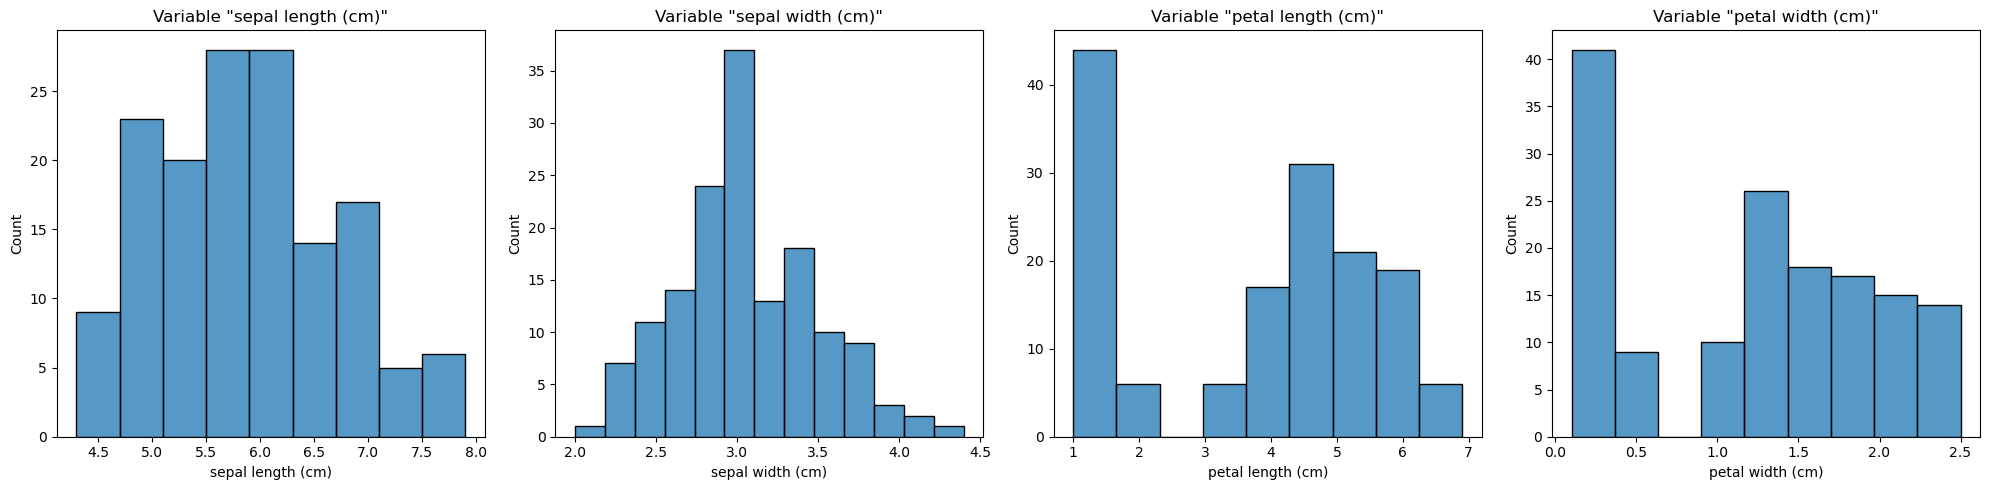

In [26]:
plt.figure(figsize=(20, 5)) # La imágen tiene que adaptarse a la cantidad de columnas

for i, col in enumerate(dataset[numerical_variables].columns):
    # Creamos un subplot
    ax = plt.subplot(1, 4, i + 1) 

    # Creamos el boxplot
    sns.histplot(data = dataset[numerical_variables], x = col, ax = ax)
    ax.set_title(f"Variable \"{col}\"")

plt.tight_layout() # Para que se separen mejor las gráficas
plt.show()

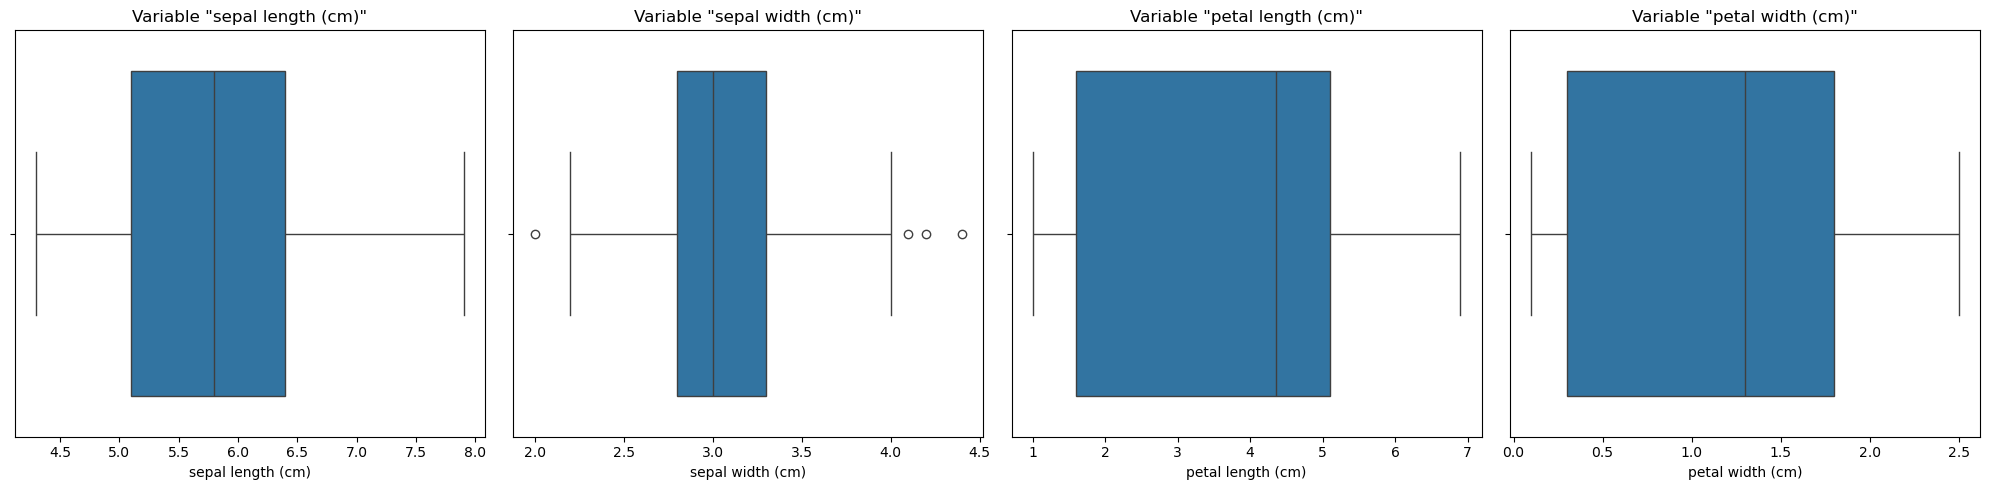

In [27]:
plt.figure(figsize=(20, 5)) # La imágen tiene que adaptarse a la cantidad de columnas

for i, col in enumerate(dataset[numerical_variables].columns):
    # Creamos un subplot
    ax = plt.subplot(1, 4, i + 1) 

    # Creamos el boxplot
    sns.boxplot(data = dataset[numerical_variables], x = col, ax = ax)
    ax.set_title(f"Variable \"{col}\"")

plt.tight_layout()
plt.show()

C:\Users\david.larrosa\AppData\Local\Temp\ipykernel_9916\423941912.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


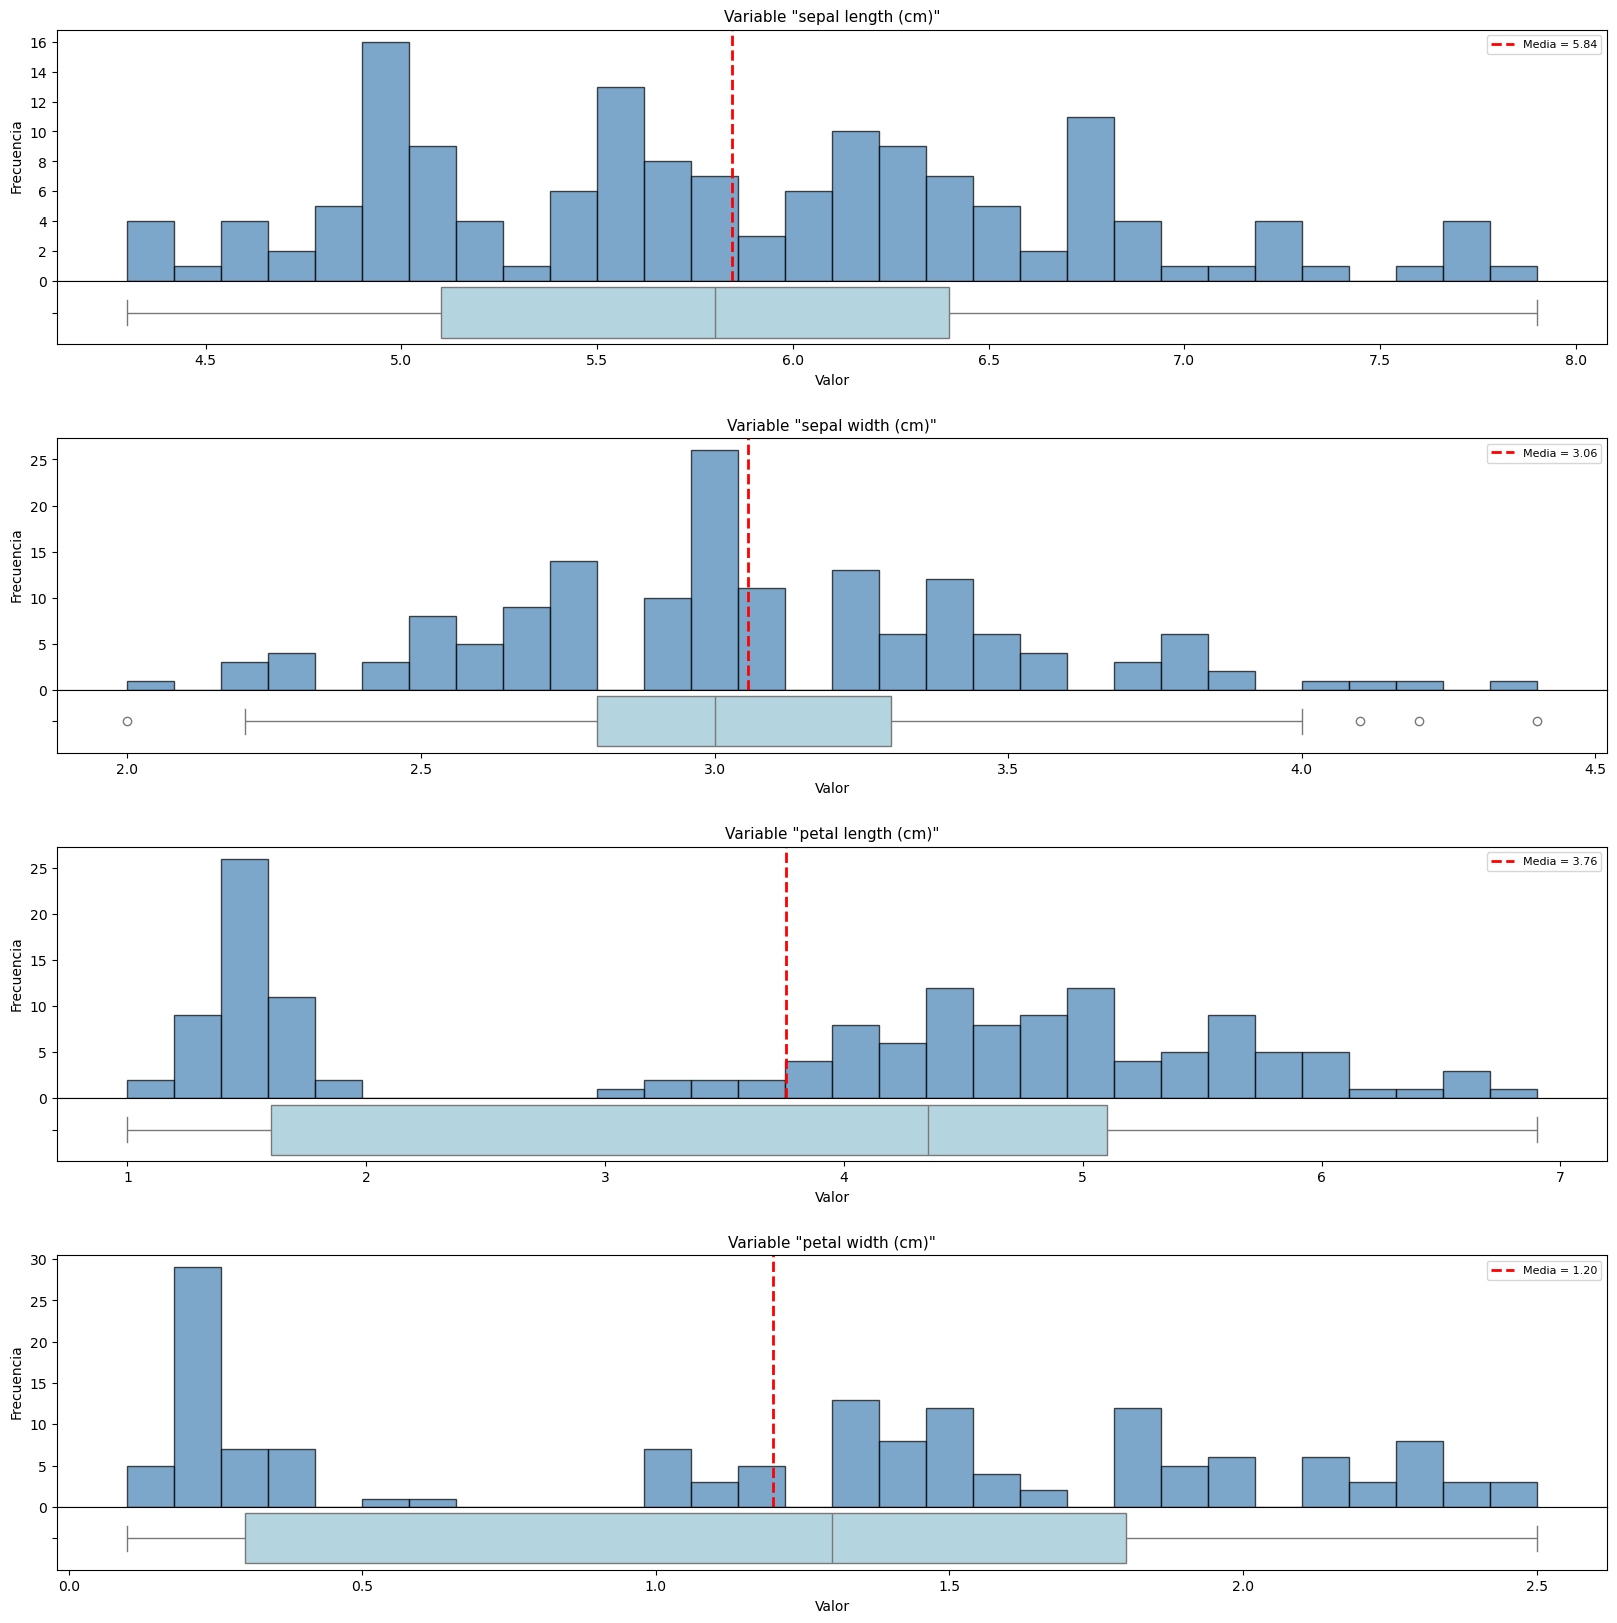

In [28]:
fig = plt.figure(figsize=(20, 5 * 4))
outer = gridspec.GridSpec(4, 1, wspace=0.2, hspace=0.3)

for i, col in enumerate(dataset[numerical_variables].columns):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], height_ratios=[4, 1], hspace=0)

    data = dataset[numerical_variables][col].dropna()
    mean_val = data.mean()

    # Histograma
    ax_hist = plt.Subplot(fig, inner[0])
    ax_hist.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Media = {mean_val:.2f}")
    ax_hist.set_title(f"Variable \"{col}\"", fontsize=11)
    ax_hist.set_ylabel("Frecuencia")
    ax_hist.set_xticks([])
    ax_hist.legend(loc='upper right', fontsize=8)
    fig.add_subplot(ax_hist)

    # Boxplot
    ax_box = plt.Subplot(fig, inner[1])
    sns.boxplot(x=data, ax=ax_box, orient="h", color="lightblue")
    ax_box.set_xlabel("Valor")
    fig.add_subplot(ax_box)

plt.tight_layout()
plt.show()

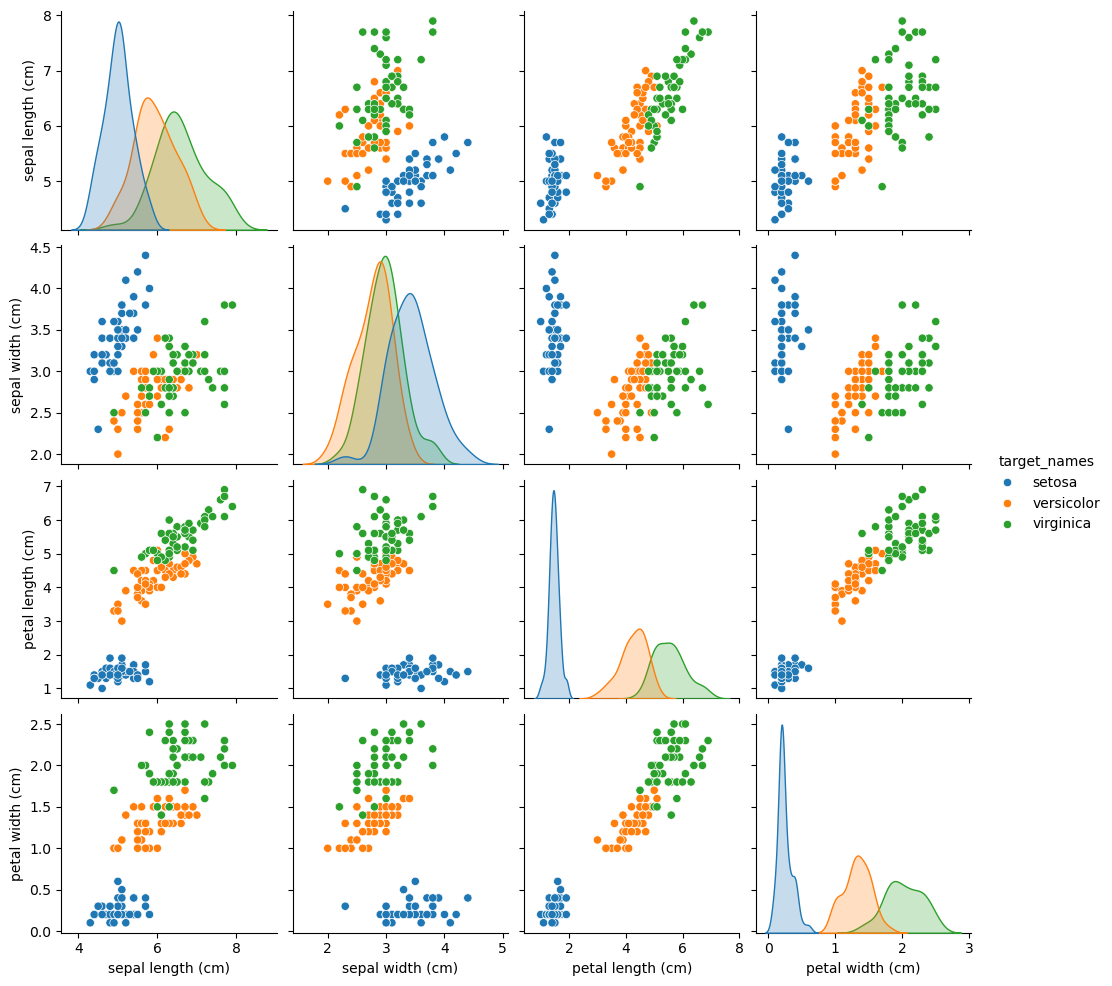

In [29]:
sns.pairplot(dataset.drop(columns="target"), hue = "target_names")

### 2. Procesamiento de variables

In [30]:
scaler = StandardScaler()
dataset_scal = scaler.fit_transform(dataset[numerical_variables])
dataset[numerical_variables] = dataset_scal

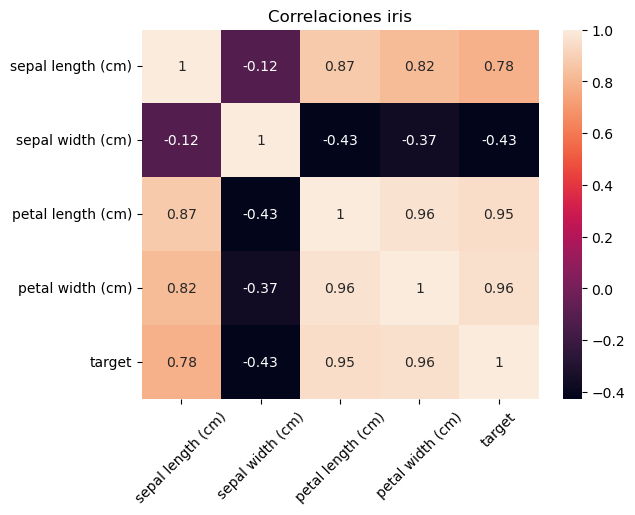

In [41]:
sns.heatmap(dataset.drop(columns="target_names").corr(), annot = True)

plt.title("Correlaciones iris")
plt.tick_params(axis = "x", rotation = 45)

plt.show()

In [49]:
x = dataset[numerical_variables]
y = dataset["target"]

### 3. Modelo

#### 3.1 Método del codo

In [50]:
min_clusters = 1
max_clusters = 20

In [53]:
# Hacemos KMeans para el rango de valores entre min_clusters y max_clusters
kmeans_model_list = [KMeans(n_clusters = k, random_state = 42).fit(x) for k in range(min_clusters, max_clusters)]

# Guardamos las inercias de cada uno de los modelos
inertias = [model.inertia_ for model in kmeans_model_list]

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

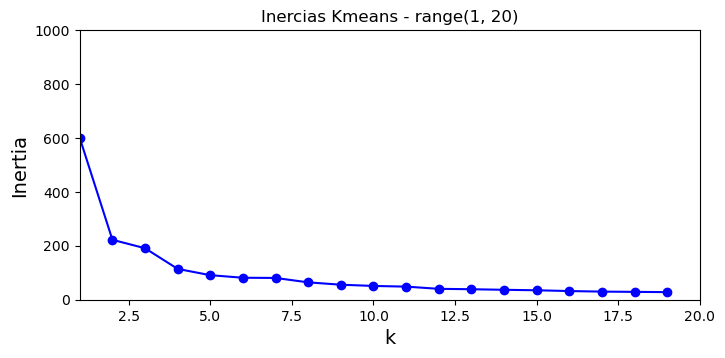

In [54]:
plt.figure(figsize=(8, 3.5))

# Visualización del rango de inercias de color azul (b), marcando los puntos (o) y uniendo con línea (-)
plt.plot(range(1, 20), inertias, "bo-")

# Titulos de los ejes
plt.xlabel("k", fontsize=14)
plt.ylabel("Inertia", fontsize=14)

plt.title(f"Inercias Kmeans - range({min_clusters}, {max_clusters})")

# Límites de los ejes
plt.axis([min_clusters, max_clusters, 0, 1000])
plt.show()

Viendo la gráfica del codo elegimos k = 5

#### 3.2 Entrenamiento del modelo

In [78]:
kmeans = KMeans(n_clusters = 5, random_state = 42, init = "k-means++")
pred = kmeans.fit(x)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [79]:
dataset[f"pred"] = pred.labels_

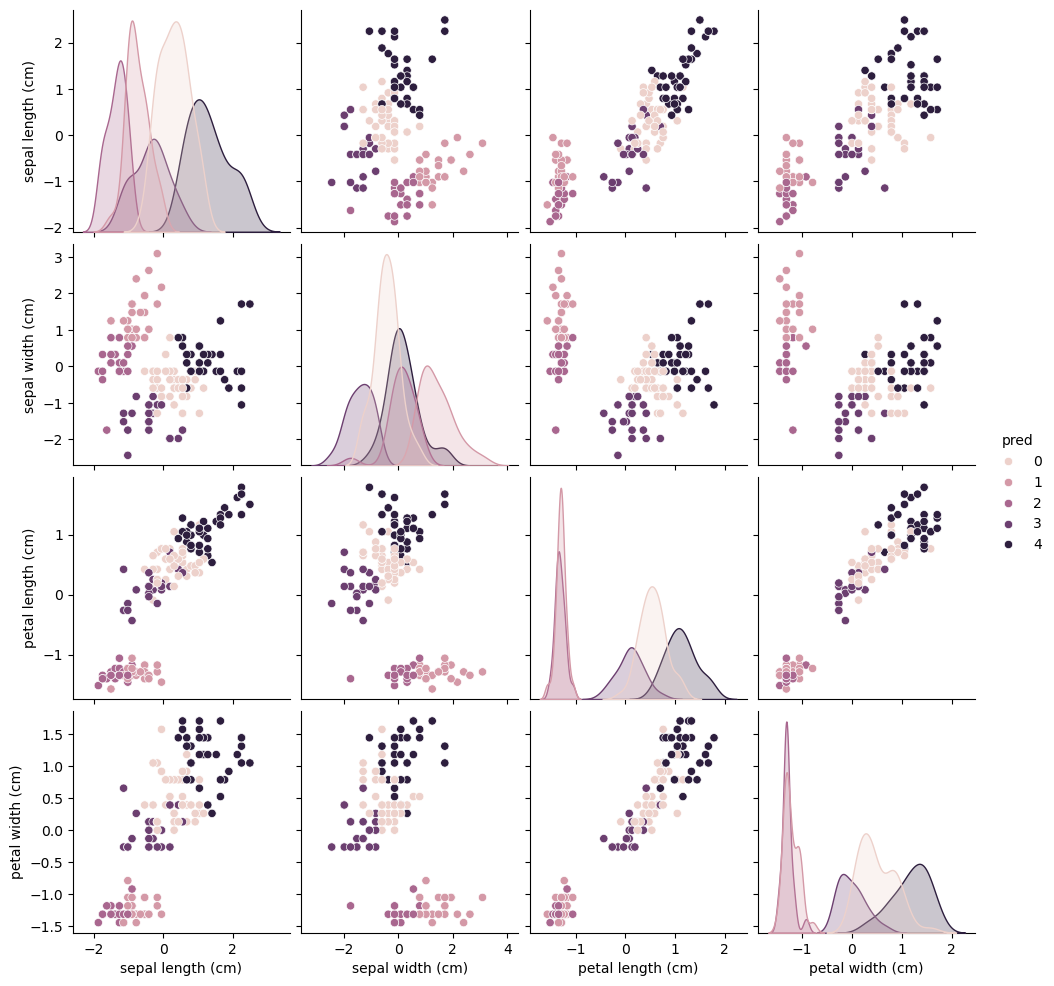

In [80]:
sns.pairplot(dataset.drop(columns=["target"]), hue = "pred")

### 4. Evaluación modelo

In [81]:
x = dataset.drop(["target", "pred", "target_names"], axis=1)
labels = dataset["pred"]

Evaluación interna

In [90]:
def calculate_inertia(x, labels):
    centroids = np.array([x[labels == i].mean(axis = 0) for i in np.unique(labels)])
    return np.sum([np.sum((x[labels == i] - centroids[i])**2) for i in np.unique(labels)])

In [94]:
print(f"Silhouette Score: {silhouette_score(x, labels)}")
print(f"Davies Bouldin Score: {davies_bouldin_score(x, labels)}")
print(f"Inertia: {calculate_inertia(x, labels)}\n\n")

Silhouette Score: 0.3450334535027462
Davies Bouldin Score: 0.9438937421182807
Inertia: 91.04766991109527




c:\ProgramData\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


Evaluación externa

In [97]:
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(dataset['target'], dataset['pred'])}")
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(dataset['target'], dataset['pred'])}")

Adjusted Rand Index (ARI): 0.4385012977881501
Normalized Mutual Information (NMI): 0.5911079189617771


In [95]:
# Crosstab
pd.crosstab(dataset["target"], dataset["pred"], rownames = ["Clase real"], colnames = ["Clúster"])

Clúster,0,1,2,3,4
Clase real,,,,,
0,0,28,22,0,0
1,28,0,0,19,3
2,17,0,0,2,31


### 5. Propuestas de mejora